In [ ]:
# ## Key Insight

#The daily returns are centered close to 0%, with most values lying in a small range and only a few outliers. This indicates a stable and reasonable return distribution across the mutual fund schemes.

In [1]:
# import libraries and data loaded 
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/02_nav_history_clean.csv")

In [2]:
# Converted date to datetime
df["date"] = pd.to_datetime(df["date"])

In [3]:
# Sorted by amfi_code and date
df = df.sort_values(["amfi_code", "date"])

In [4]:
# Calculated daily_return using pct_change()
df["daily_return"] = (
    df.groupby("amfi_code")["nav"]
      .pct_change()
)

In [5]:
# Removed first-row NaN values
df = df.dropna(subset=["daily_return"])

In [6]:
print(df.head())

      amfi_code       date       nav  daily_return
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639


In [7]:
# Checked describe() output
print(df["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


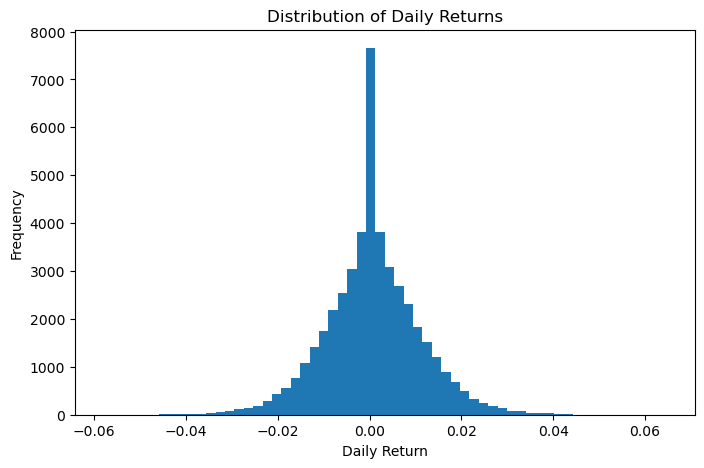

In [8]:
#Validated the distribution (mean, std, min, max look reasonable)
plt.figure(figsize=(8,5))

plt.hist(
    df["daily_return"],
    bins=60
)

plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Returns")

plt.savefig("../reports/15_daily_return_distribution.png")

plt.show()

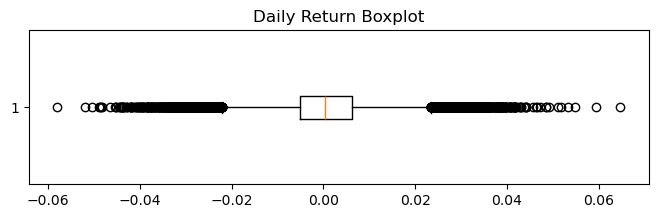

In [9]:
# Created and saved boxplot
plt.figure(figsize=(8,2))

plt.boxplot(df["daily_return"], vert=False)

plt.title("Daily Return Boxplot")

plt.savefig("../reports/16_daily_return_boxplot.png")

plt.show()

In [10]:
print(df["daily_return"].min())
print(df["daily_return"].max())

-0.058102013949189124
0.06471309359097144


In [11]:
print(df["daily_return"].isnull().sum())

0


In [12]:
# Saved nav_history_daily_returns.csv
df.to_csv(
    "../data/processed/nav_history_daily_returns.csv",
    index=False
)

print("Daily returns saved successfully!")

Daily returns saved successfully!
